# Analisis Hubungan PDRB dan IPM Tahun 2024

Notebook ini bertujuan untuk menganalisis hubungan antara Produk Domestik Regional Bruto (PDRB) dan Indeks Pembangunan Manusia (IPM) di 38 provinsi Indonesia menggunakan data tahun 2024.

Analisis yang dilakukan meliputi:
1.  **Analisis Korelasi Pearson**: Untuk mengukur kekuatan dan arah hubungan linear.
2.  **Visualisasi Scatter Plot**: Untuk melihat pola hubungan secara visual.
3.  **Analisis Regresi Linear Sederhana**: Untuk memodelkan pengaruh PDRB terhadap IPM.

In [1]:
import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

# Data PDRB 2024
csv_data_pdrb_2024 = """Provinsi,Produk Domestik Bruto/Produk Domestik Regional Bruto Atas Dasar Harga Konstan 2010 (Rp)
Aceh,153780.44
Sumatera Utara,632534.73
Sumatera Barat,199407.38
Riau,571233.59
Jambi,176906.5
Sumatera Selatan,379119.63
Bengkulu,54454.65
Lampung,281557.2
Kepulauan Bangka Belitung,60802.64
Kepulauan Riau,209939.07
DKI Jakarta,2151041.33
Jawa Barat,1752071.2
Jawa Tengah,1157025.94
DI Yogyakarta,124590.45
Jawa Timur,1935810.15
Banten,531735.25
Bali,168186.03
Nusa Tenggara Barat,109414.97
Nusa Tenggara Timur,78044.57
Kalimantan Barat,162574.47
Kalimantan Tengah,118682.32
Kalimantan Selatan,156756.94
Kalimantan Timur,570824.01
Kalimantan Utara,73007.99
Sulawesi Utara,107575.01
Sulawesi Tengah,212281.54
Sulawesi Selatan,396141.74
Sulawesi Tenggara,113989.49
Gorontalo,32949.62
Sulawesi Barat,37088.07
Maluku,37209.36
Maluku Utara,55152.33
Papua Barat,49486.23
Papua Barat Daya,24873.72
Papua,51587.16
Papua Selatan,18963.85
Papua Tengah,105471.48
Papua Pegunungan,13798.74"""
data_io_pdrb_2024 = io.StringIO(csv_data_pdrb_2024)
df_pdrb_2024 = pd.read_csv(data_io_pdrb_2024)
df_pdrb_2024.rename(columns={'Produk Domestik Bruto/Produk Domestik Regional Bruto Atas Dasar Harga Konstan 2010 (Rp)': 'PDRB_Konstan_2010_Miliar'}, inplace=True)

# Data IPM 2024
csv_data_ipm_2024 = """Provinsi,2024
ACEH,74.03
SUMATERA UTARA,74.02
SUMATERA BARAT,74.49
RIAU,74.79
JAMBI,73.43
SUMATERA SELATAN,72.3
BENGKULU,73.39
LAMPUNG,71.81
KEP. BANGKA BELITUNG,73.33
KEP. RIAU,77.97
DKI JAKARTA,83.08
JAWA BARAT,74.43
JAWA TENGAH,73.88
DI YOGYAKARTA,81.55
JAWA TIMUR,74.09
BANTEN,74.48
BALI,77.76
NUSA TENGGARA BARAT,70.93
NUSA TENGGARA TIMUR,67.39
KALIMANTAN BARAT,70.13
KALIMANTAN TENGAH,72.73
KALIMANTAN SELATAN,73.03
KALIMANTAN TIMUR,78.83
KALIMANTAN UTARA,73.02
SULAWESI UTARA,75.03
SULAWESI TENGAH,71.56
SULAWESI SELATAN,74.05
SULAWESI TENGGARA,73.48
GORONTALO,71.23
SULAWESI BARAT,68.2
MALUKU,71.57
MALUKU UTARA,71.03
PAPUA BARAT,67.02
PAPUA BARAT DAYA,68.63
PAPUA,73
PAPUA SELATAN,67.9
PAPUA TENGAH,59.75
PAPUA PEGUNUNGAN,53.42
INDONESIA,74.2"""
data_io_ipm_2024 = io.StringIO(csv_data_ipm_2024)
df_ipm_2024 = pd.read_csv(data_io_ipm_2024)
df_ipm_2024.rename(columns={'2024': 'IPM_2024'}, inplace=True)
df_ipm_2024 = df_ipm_2024[df_ipm_2024['Provinsi'] != 'INDONESIA']

# Normalisasi nama provinsi dan gabungkan data
df_pdrb_2024['Provinsi_Upper'] = df_pdrb_2024['Provinsi'].str.upper().str.replace('KEPULAUAN', 'KEP.').str.strip()
df_ipm_2024['Provinsi_Upper'] = df_ipm_2024['Provinsi'].str.upper().str.replace('KEPULAUAN', 'KEP.').str.strip()
df_merged_2024 = pd.merge(df_pdrb_2024, df_ipm_2024, on='Provinsi_Upper')
df_merged_2024 = df_merged_2024.drop(columns=['Provinsi_Upper', 'Provinsi_y'])
df_merged_2024.rename(columns={'Provinsi_x': 'Provinsi'}, inplace=True)

print("Data PDRB dan IPM 2024 berhasil digabungkan.")
df_merged_2024.head()

Data PDRB dan IPM 2024 berhasil digabungkan.


,Provinsi,PDRB_Konstan_2010_Miliar,IPM_2024
0,Aceh,153780.44,74.03
1,Sumatera Utara,632534.73,74.02
2,Sumatera Barat,199407.38,74.49
3,Riau,571233.59,74.79
4,Jambi,176906.50,73.43


## 1. Analisis Korelasi

In [2]:
correlation, p_value = pearsonr(df_merged_2024['PDRB_Konstan_2010_Miliar'], df_merged_2024['IPM_2024'])

print(f"Koefisien Korelasi Pearson (r): {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Hubungan antara PDRB dan IPM adalah signifikan secara statistik.")
else:
    print("Hubungan antara PDRB dan IPM tidak signifikan secara statistik.")

Koefisien Korelasi Pearson (r): 0.4026
P-value: 0.0122
Hubungan antara PDRB dan IPM adalah signifikan secara statistik.


## 2. Visualisasi Scatter Plot

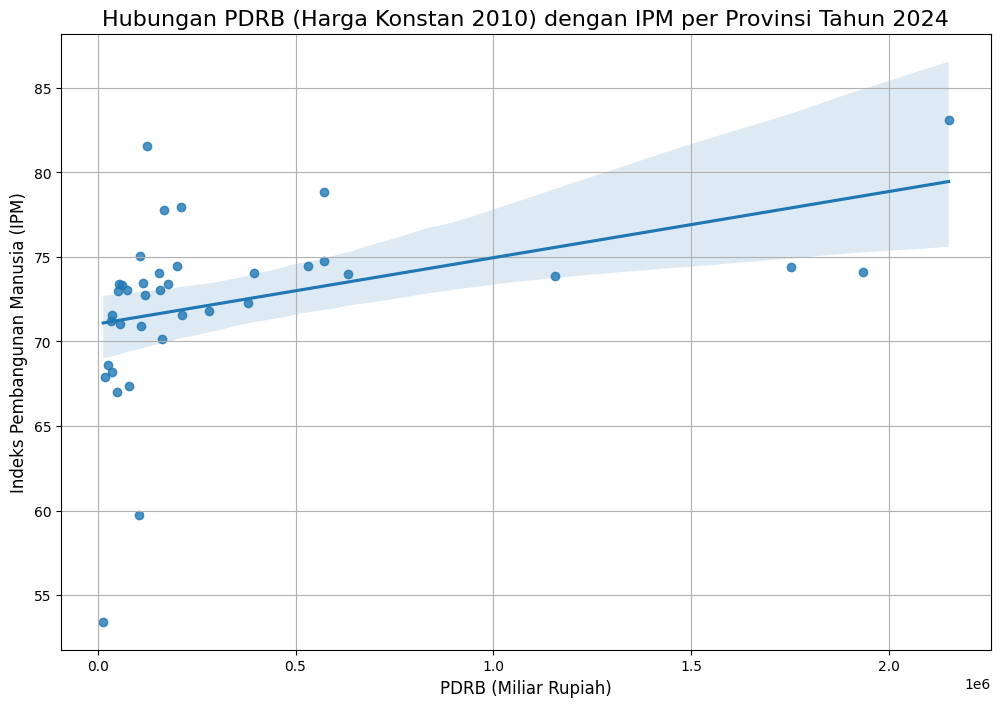

In [3]:
plt.figure(figsize=(12, 8))
sns.regplot(data=df_merged_2024, x='PDRB_Konstan_2010_Miliar', y='IPM_2024')

plt.title('Hubungan PDRB (Harga Konstan 2010) dengan IPM per Provinsi Tahun 2024', fontsize=16)
plt.xlabel('PDRB (Miliar Rupiah)', fontsize=12)
plt.ylabel('Indeks Pembangunan Manusia (IPM)', fontsize=12)
plt.grid(True)
plt.show()

## 3. Analisis Regresi Linear Sederhana

In [4]:
X = df_merged_2024['PDRB_Konstan_2010_Miliar']
y = df_merged_2024['IPM_2024']

# Menambahkan konstanta (intercept) ke model
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               IPM_2024   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     6.965
Date:                Sat, 19 Jul 2025   Prob (F-statistic):             0.0122
Time:                        21:11:19   Log-Likelihood:                -112.34
No. Observations:                  38   AIC:                             228.7
Df Residuals:                      36   BIC:                             231.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   